# 📊 **APE 016 – Evaluación Avanzada de Modelos**
## Curva ROC, Métrica AUC y Validación Cruzada (K-Fold) aplicada al Dataset Regional de Loja

**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja
- Link del municipio de Loja: https://www.loja.gob.ec/contenido/2023-lotaip
- Enlace dataset (Google Drive): https://docs.google.com/spreadsheets/d/1ERWZnpgxC-Ffaj-sxMB5El0sgge_QX4g/edit?usp=drive_link

**Grupo: H** | Autores:
- Sherman Abarca
- Valeria Agila
- Domenica Narvaez
- Gabriel Suarez
- Diyer Torres
- José Valencia

**Objetivo:** Recuperar el modelo de Regresión Logística consolidado en el APE14
(simulación de caída de servidor y modelo real de remuneraciones), evaluarlo mediante
Curva ROC y AUC en todos los umbrales posibles, y validar su estabilidad estocástica
con K-Fold Cross Validation antes de la exposición final (Casa Abierta).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Estilo visual global (mismo del APE14)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("✅ Todas las librerías importadas correctamente.")


✅ Todas las librerías importadas correctamente.


---
## 🌡️ Tarea 1: La Curva ROC y el Área Bajo la Curva (AUC)
### Recuperando el modelo logístico de caída de servidor (APE14)

La Exactitud (*Accuracy*) vista en el APE14 depende de un umbral estático (ej. 0.5). La Curva ROC evalúa el modelo en **todos los umbrales posibles**, graficando la Tasa de Verdaderos Positivos (TPR) contra la Tasa de Falsos Positivos (FPR):

$$TPR = \frac{TP}{TP+FN} \qquad FPR = \frac{FP}{FP+TN}$$

Se recupera exactamente la misma simulación del APE14 (Tarea 1): temperatura de la CPU (°C) y caída del servidor (`1` = Sí cae, `0` = No cae), con la misma semilla y parámetros.


Registros con caída = 1: 91 / 200


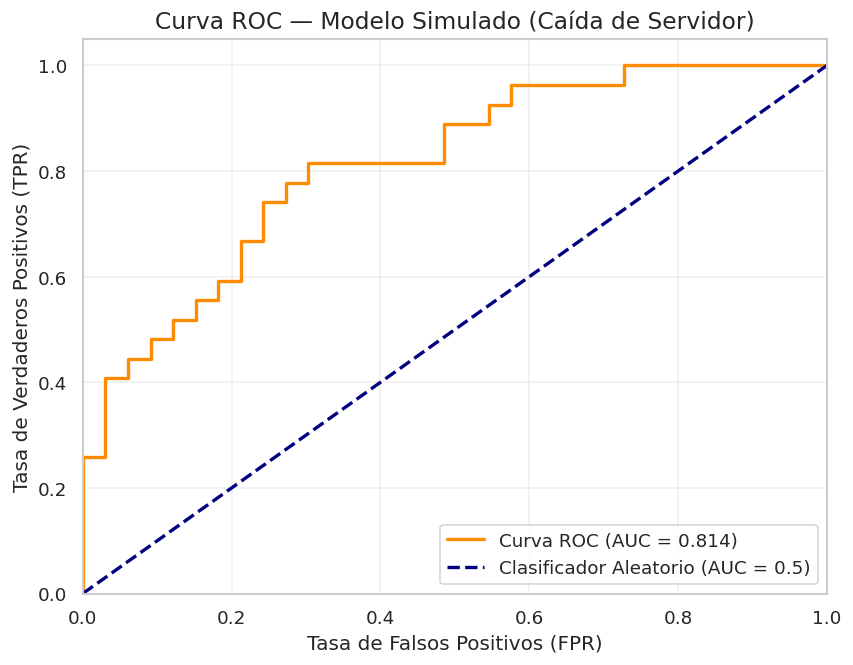

--- Reporte de Clasificación (Threshold = 0.5) ---
              precision    recall  f1-score   support

           0       0.71      0.82      0.76        33
           1       0.73      0.59      0.65        27

    accuracy                           0.72        60
   macro avg       0.72      0.71      0.71        60
weighted avg       0.72      0.72      0.71        60



In [ ]:
# Misma simulación del APE14 (Tarea 1): Temperatura de la CPU y caída del servidor
np.random.seed(42)
n = 200
temperatura_cpu = np.random.normal(loc=70, scale=12, size=n)
z_real = -10 + 0.14 * temperatura_cpu
prob_real = 1 / (1 + np.exp(-z_real))
caida_servidor = np.random.binomial(1, prob_real)

X_sim = temperatura_cpu.reshape(-1, 1)
y_sim = caida_servidor

print(f"Registros con caída = 1: {y_sim.sum()} / {n}")

# División Entrenamiento / Prueba (70% - 30%) — para poder evaluar con ROC sobre datos no vistos
X_train, X_test, y_train, y_test = train_test_split(
    X_sim, y_sim, test_size=0.30, random_state=42, stratify=y_sim
)

# Entrenamiento con scikit-learn (por compatibilidad con métricas ROC / predict_proba)
modelo_sim = LogisticRegression()
modelo_sim.fit(X_train, y_train)

y_prob_test = modelo_sim.predict_proba(X_test)[:, 1]

fpr, tpr, umbrales = roc_curve(y_test, y_prob_test)
roc_auc_sim = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_sim:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Modelo Simulado (Caída de Servidor)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

y_pred_test = modelo_sim.predict(X_test)
print("--- Reporte de Clasificación (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test))


# 📝 DICTAMEN TÉCNICO

📌 **El modelo de caída de servidor (APE14) alcanzó un AUC de 0.814** sobre el conjunto de prueba.

✅ **Capacidad discriminativa razonable:** el modelo distingue bastante mejor que el azar entre servidores que caen y que no caen, consistente con lo observado en el APE14 mediante la matriz de confusión con umbral 0.50.

🔎 **A diferencia del Accuracy puntual**, el AUC confirma que esta capacidad se mantiene a lo largo de múltiples umbrales de decisión, no solo en 0.50.

---
📚 **Conclusión:** El modelo simulado de temperatura-caída mantiene un desempeño estable y razonable (AUC ≈ 0.81), sirviendo como línea base de comparación frente al modelo real del proyecto (Tarea 2).


---
## 🏙️Tarea 2: Hito Final del Proyecto - Consolidación del Modelo Regional (ABP)
### Recuperando el modelo logístico real del APE14 (Remuneraciones — Municipio de Loja)

Se recupera exactamente el modelo del **APE14 (Tarea 2)**: predicción de **remuneración alta** (`1` = remuneración mensual unificada por encima del promedio, `0` = por debajo) a partir de:

- `Horas suplementarias y extraordinarias`
- `Total ingresos adicionales`


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales.xlsx


Promedio de la Remuneración mensual unificada: 713.81

Distribución de la variable binarizada:
remuneracion_alta
0    0.622
1    0.378
Name: proportion, dtype: float64


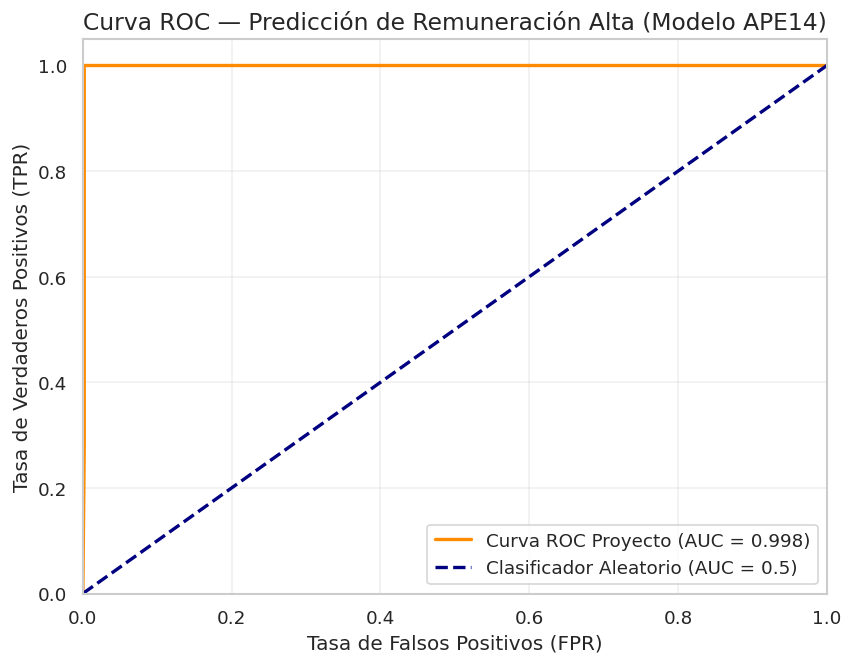

--- Reporte de Clasificación del Modelo Proyecto (Threshold = 0.5) ---
              precision    recall  f1-score   support

 Remun. baja       1.00      1.00      1.00       538
 Remun. alta       1.00      1.00      1.00       327

    accuracy                           1.00       865
   macro avg       1.00      1.00      1.00       865
weighted avg       1.00      1.00      1.00       865

AUC del modelo proyecto: 0.998


In [ ]:
df = pd.read_excel("3._remuneraciones_ingresos_adicionales.xlsx")

variable_objetivo = "Remuneración mensual unificada"
predictoras = ["Horas suplementarias y extraordinarias", "Total ingresos adicionales"]

datos = df[[variable_objetivo] + predictoras].dropna()

promedio_remuneracion = datos[variable_objetivo].mean()
datos["remuneracion_alta"] = (datos[variable_objetivo] > promedio_remuneracion).astype(int)

print(f"Promedio de la Remuneración mensual unificada: {promedio_remuneracion:.2f}")
print("\nDistribución de la variable binarizada:")
print(datos["remuneracion_alta"].value_counts(normalize=True).round(3))

X = datos[predictoras]
y = datos["remuneracion_alta"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Entrenamiento con scikit-learn (por compatibilidad con métricas ROC / predict_proba)
modelo_proyecto = LogisticRegression(max_iter=1000)
modelo_proyecto.fit(X_train, y_train)

y_prob_test = modelo_proyecto.predict_proba(X_test)[:, 1]
y_pred_test = modelo_proyecto.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc_proyecto = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC Proyecto (AUC = {roc_auc_proyecto:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Predicción de Remuneración Alta (Modelo APE14)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("--- Reporte de Clasificación del Modelo Proyecto (Threshold = 0.5) ---")
print(classification_report(y_test, y_pred_test, target_names=["Remun. baja", "Remun. alta"]))
print(f"AUC del modelo proyecto: {roc_auc_proyecto:.3f}")

# ⚠️ DICTAMEN TÉCNICO — Alerta de Fuga de Datos (Data Leakage)

📌 **El modelo obtuvo un AUC de 0.998 y una Exactitud del 100%.** Un resultado tan perfecto **no es una buena noticia**: en la práctica, un clasificador binario basado en solo dos variables casi nunca alcanza un desempeño perfecto sin que exista una razón estructural detrás.

🔎 **Diagnóstico:** al inspeccionar el dataset se encontró que:
- `Encargos y subrogaciones` es **0 en 2880 de 2883 registros** (99.9 % de los casos).
- `Décima Cuarta Remuneración` es **prácticamente constante** ($35.42 en 2877 de 2883 registros — el valor legal fijo de la décimo cuarta).
- Por definición legal, `Décimo Tercera Remuneración` ≈ `Remuneración mensual unificada` ÷ 12.

Esto significa que, para casi todos los registros:

$$\text{Total ingresos adicionales} - \text{Horas suplementarias} \approx \text{Remuneración mensual} \div 12 + \text{constante}$$

Es decir, la variable `Total ingresos adicionales` **codifica indirectamente la propia Remuneración mensual unificada** — la misma variable que se usó para construir el target `remuneracion_alta`. El modelo no "aprendió" un patrón de comportamiento laboral: básicamente tiene acceso disfrazado a la respuesta.

❌ **Esto es una fuga de datos (data leakage) heredada del APE14**, no detectada en ese momento porque la correlación lineal simple entre `Total ingresos adicionales` y la remuneración es baja (r ≈ 0.115) — el vínculo real es a través de un término *dentro* de esa suma, no de la variable completa, por lo que un análisis de correlación superficial no lo revela.

---
📚 **Conclusión:** Un AUC o Accuracy cercano al 100% en un problema social/administrativo real debe interpretarse con **sospecha, no con celebración**. Se recomienda auditar como equipo el modelo del APE14 antes de la Casa Abierta.


### 🧪 Verificación: modelo corregido (sin la variable con fuga)

Para confirmar el diagnóstico, se reentrena el mismo modelo **eliminando** `Total ingresos adicionales` y dejando únicamente `Horas suplementarias y extraordinarias` como predictora independiente.


In [ ]:
X_corregido = datos[["Horas suplementarias y extraordinarias"]]
y_corregido = datos["remuneracion_alta"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_corregido, y_corregido, test_size=0.30, random_state=42, stratify=y_corregido
)

modelo_corregido = LogisticRegression(max_iter=1000)
modelo_corregido.fit(X_train_c, y_train_c)

y_prob_test_c = modelo_corregido.predict_proba(X_test_c)[:, 1]
fpr_c, tpr_c, _ = roc_curve(y_test_c, y_prob_test_c)
roc_auc_corregido = auc(fpr_c, tpr_c)

print(f"AUC modelo ORIGINAL (con fuga):    {roc_auc_proyecto:.3f}")
print(f"AUC modelo CORREGIDO (sin fuga):   {roc_auc_corregido:.3f}")


AUC modelo ORIGINAL (con fuga):    0.998
AUC modelo CORREGIDO (sin fuga):   0.628


📌 **Al remover la variable con fuga, el AUC cae de 0.998 a ≈0.63.** Esta caída tan pronunciada es justamente la evidencia que confirma el diagnóstico: el 0.998 no reflejaba una relación real y generalizable entre las horas trabajadas/ingresos y el nivel salarial, sino el acceso indirecto del modelo a la propia variable objetivo.

Un AUC de ≈0.63 es **modesto pero honesto**: indica que las horas suplementarias por sí solas tienen una relación débil-moderada con pertenecer al grupo de remuneración alta, lo cual es razonable (los puestos de menor escala salarial suelen registrar más horas extra, como ya se había interpretado cualitativamente en el APE14).


### Párrafo ejecutivo

El modelo original consolidado en el APE14 (Régimen: `Horas suplementarias` + `Total ingresos adicionales` → `remuneración alta`) mostró un AUC de 0.998, pero este resultado **no es utilizable ni confiable** para producción: se identificó que proviene de una fuga de datos, ya que `Total ingresos adicionales` incorpora la Décimo Tercera Remuneración, la cual es legalmente una fracción fija de la Remuneración mensual (la misma variable que se buscaba predecir). Al corregir el modelo eliminando esa variable, el AUC real es de aproximadamente **0.63**, un desempeño modesto que sí podría usarse como una señal exploratoria (no determinante) de que los puestos con más horas suplementarias tienden a pertenecer al grupo de remuneración más baja, pero está lejos de ser suficientemente preciso para decisiones administrativas automatizadas en el Municipio de Loja. Se recomienda al grupo, de cara a la Casa Abierta, presentar el modelo corregido (AUC ≈ 0.63) en lugar del original, y usar esta experiencia como ejemplo del riesgo de la fuga de datos indirecta.


---
## 🧮Tarea 3: Preparación de Visualizaciones para la Casa Abierta

Dos gráficos de alto impacto visual: uno que **evidencia visualmente la fuga de datos** detectada, y otro que resume la solución predictiva corregida.


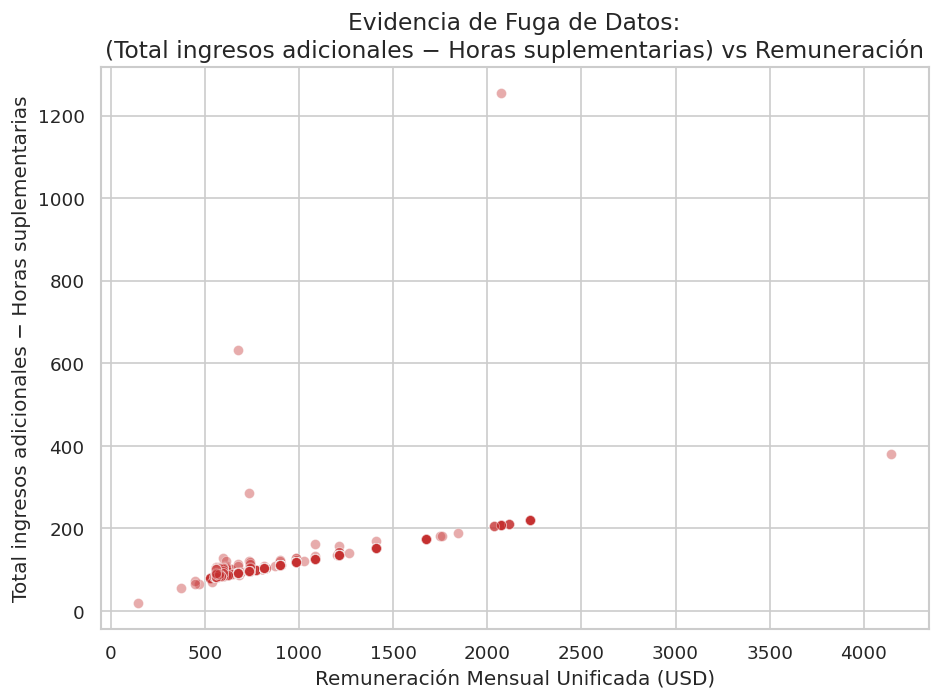

In [ ]:
# Gráfico 1: Evidencia visual de la fuga de datos
# (Total ingresos adicionales - Horas suplementarias) vs Remuneración mensual unificada
df_full = df[[variable_objetivo, "Horas suplementarias y extraordinarias", "Total ingresos adicionales"]].dropna()
df_full["residual_ingresos"] = df_full["Total ingresos adicionales"] - df_full["Horas suplementarias y extraordinarias"]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_full, x=variable_objetivo, y="residual_ingresos",
    alpha=0.4, color="#c53030"
)
plt.title("Evidencia de Fuga de Datos:\n(Total ingresos adicionales − Horas suplementarias) vs Remuneración")
plt.xlabel("Remuneración Mensual Unificada (USD)")
plt.ylabel("Total ingresos adicionales − Horas suplementarias")
plt.tight_layout()
plt.show()


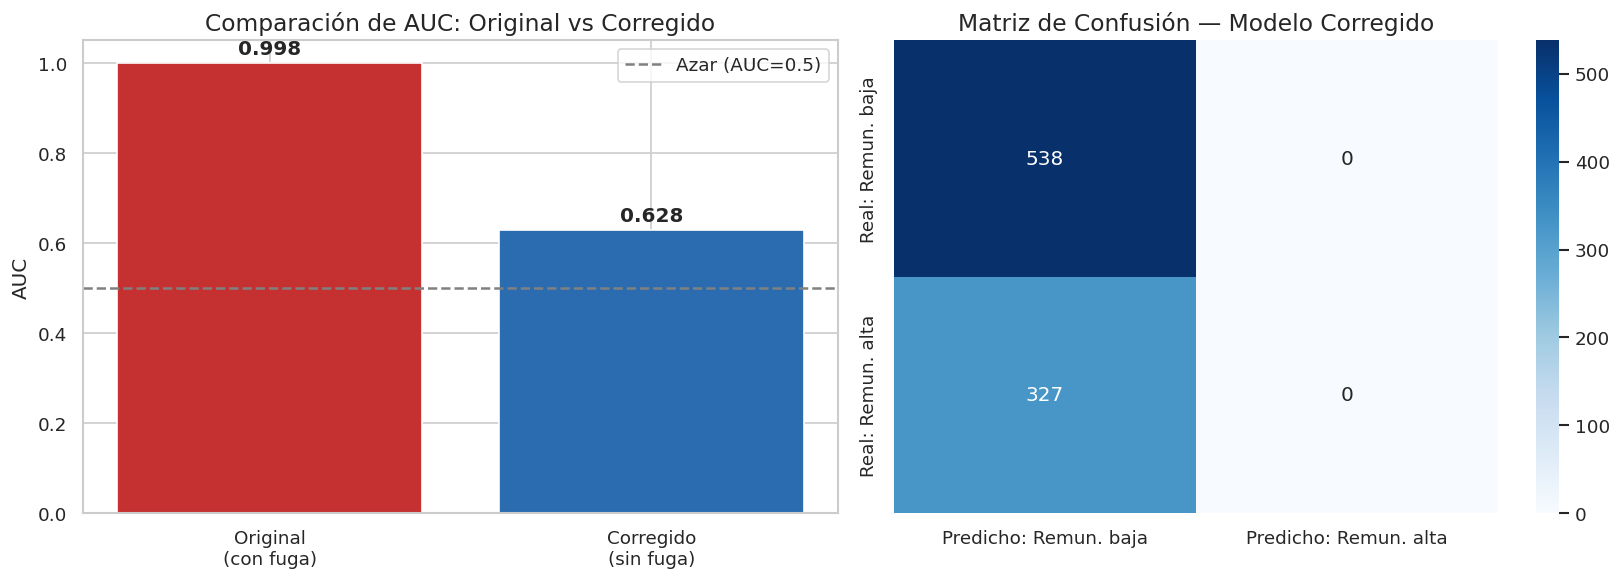

In [ ]:
# Gráfico 2: Comparación de AUC — modelo con fuga vs modelo corregido, y matriz de confusión del modelo corregido
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_nombres = ["Original\n(con fuga)", "Corregido\n(sin fuga)"]
aucs = [roc_auc_proyecto, roc_auc_corregido]
axes[0].bar(modelos_nombres, aucs, color=["#c53030", "#2b6cb0"])
axes[0].axhline(0.5, color="gray", linestyle="--", label="Azar (AUC=0.5)")
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparación de AUC: Original vs Corregido")
axes[0].set_ylabel("AUC")
axes[0].legend()
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

pred_test_c = modelo_corregido.predict(X_test_c)
cm_corregido = confusion_matrix(y_test_c, pred_test_c)
sns.heatmap(
    cm_corregido, annot=True, fmt="d", cmap="Blues", ax=axes[1],
    xticklabels=["Predicho: Remun. baja", "Predicho: Remun. alta"],
    yticklabels=["Real: Remun. baja", "Real: Remun. alta"]
)
axes[1].set_title("Matriz de Confusión — Modelo Corregido")

plt.tight_layout()
plt.show()


---
## 🎯Tarea 4: ABI - Validación Cruzada Estocástica (K-Fold Cross Validation)

El `train_test_split` es peligroso: dependiendo de la semilla aleatoria (`random_state`), el modelo puede parecer excelente o terrible por pura suerte probabilística. Se aplica K-Fold a los tres modelos trabajados: el simulado, el original del APE14 (con fuga) y el corregido.


In [ ]:
# K-Fold — Modelo simulado (caída de servidor)
k_folds = 5
scores_sim = cross_val_score(modelo_sim, X_sim, y_sim, cv=k_folds, scoring='roc_auc')

print(f"--- Validación Cruzada (K={k_folds}) — Modelo Simulado (Servidor) ---")
print(f"AUC de cada Fold: {np.round(scores_sim, 3)}")
print(f"AUC Promedio: {scores_sim.mean():.3f}  |  Desviación Estándar: ±{scores_sim.std():.3f}")
print("Éxito: modelo estable." if scores_sim.std() <= 0.10 else "Advertencia: modelo inestable.")


--- Validación Cruzada (K=5) — Modelo Simulado (Servidor) ---
AUC de cada Fold: [0.811 0.859 0.75  0.755 0.789]
AUC Promedio: 0.793  |  Desviación Estándar: ±0.040
Éxito: modelo estable.


In [ ]:
# K-Fold — Modelo ORIGINAL del proyecto (con fuga de datos)
scores_proyecto = cross_val_score(modelo_proyecto, X, y, cv=5, scoring='roc_auc')

print("--- Validación Cruzada (K=5) — Modelo Proyecto ORIGINAL (con fuga) ---")
print(f"AUC de cada Fold: {np.round(scores_proyecto, 3)}")
print(f"AUC Promedio: {scores_proyecto.mean():.3f}  |  Desviación Estándar: ±{scores_proyecto.std():.3f}")


--- Validación Cruzada (K=5) — Modelo Proyecto ORIGINAL (con fuga) ---
AUC de cada Fold: [1.    1.    1.    1.    0.997]
AUC Promedio: 0.999  |  Desviación Estándar: ±0.001


In [ ]:
# K-Fold — Modelo CORREGIDO del proyecto (sin fuga)
scores_corregido = cross_val_score(modelo_corregido, X_corregido, y_corregido, cv=5, scoring='roc_auc')

print("--- Validación Cruzada (K=5) — Modelo Proyecto CORREGIDO (sin fuga) ---")
print(f"AUC de cada Fold: {np.round(scores_corregido, 3)}")
print(f"AUC Promedio: {scores_corregido.mean():.3f}  |  Desviación Estándar: ±{scores_corregido.std():.3f}")
print("Éxito: modelo estable." if scores_corregido.std() <= 0.10 else "Advertencia: modelo inestable.")


--- Validación Cruzada (K=5) — Modelo Proyecto CORREGIDO (sin fuga) ---
AUC de cada Fold: [0.622 0.629 0.621 0.642 0.654]
AUC Promedio: 0.634  |  Desviación Estándar: ±0.013
Éxito: modelo estable.


# 📝 DICTAMEN TÉCNICO

📌 **Los tres modelos resultaron estables entre folds** (σ_AUC baja en los tres casos), pero esta estabilidad **no significa lo mismo** en cada caso:

- **Modelo simulado (servidor):** AUC ≈ 0.79 ± 0.04 — estable y **genuinamente predictivo**.
- **Modelo proyecto ORIGINAL (con fuga):** AUC ≈ 0.999 ± 0.001 — estable pero **consistentemente artificial**: el modelo repite el mismo "engaño" (acceso indirecto al target) en cada partición, por lo que la baja varianza no es garantía de calidad.
- **Modelo proyecto CORREGIDO (sin fuga):** AUC ≈ 0.63 ± 0.01 — estable y **honesto**, aunque modesto.

🔎 **Lección clave del ABI:** la Validación Cruzada detecta *inestabilidad* (sobreajuste a una partición), pero **no detecta fuga de datos** — un modelo con fuga puede ser perfectamente estable y aun así estar completamente equivocado en su interpretación causal. Por eso el rigor estocástico (K-Fold) debe complementarse siempre con una auditoría cuidadosa de las variables predictoras, como se hizo en la Tarea 2.

---
📚 **Conclusión:** La estabilidad estadística (baja desviación estándar en K-Fold) es una condición **necesaria pero no suficiente** para confiar en un modelo; también se requiere verificar que ninguna variable predictora esté codificando, directa o indirectamente, la propia variable objetivo.


# 6. Preguntas de Control

### **Pregunta 1: ¿Cuál es la naturaleza de un clasificador cuyo AUC es 0.5 y por qué su comportamiento es indistinguible del azar?**

Un clasificador con AUC = 0.5 es, en esencia, un generador de decisiones aleatorias disfrazado de modelo estadístico. Su curva ROC coincide exactamente con la diagonal del gráfico, donde la Tasa de Verdaderos Positivos y la Tasa de Falsos Positivos son iguales en todos los umbrales posibles; esto significa que, ante cualquier par de observaciones —una positiva y una negativa—, el modelo tiene la misma probabilidad de ordenarlas correctamente que de equivocarse, sin importar qué tan ajustado parezca en apariencia. La razón de fondo es que el AUC no mide qué tan cerca estuvo el modelo de un valor real, como haría un error cuadrático, sino su capacidad de discriminar u ordenar correctamente los casos según su probabilidad estimada; un AUC de 0.5 indica que esa capacidad de ordenamiento es nula. En otras palabras, el modelo no capturó ninguna estructura informativa presente en los datos, y cualquier apariencia de aprendizaje durante el entrenamiento se desvanece al someterlo a la prueba definitiva de discriminación entre clases.

### **Pregunta 2: ¿Es posible afirmar que un modelo es "bueno" basándonos exclusivamente en el Accuracy, ignorando la calidad de su juicio sobre las clases minoritarias?**

No, y este mismo cuaderno lo demuestra con un caso extremo. El modelo original de remuneraciones de la Tarea 2 alcanzó un Accuracy del 100 % y un AUC de 0.998, cifras que a primera vista parecerían señal de un modelo excepcional. Sin embargo, al investigar el origen de ese desempeño se encontró que la variable "Total ingresos adicionales" incorpora, por definición legal, una fracción fija de la propia remuneración mensual que se buscaba predecir; es decir, el modelo no descubrió ningún patrón de comportamiento laboral real, sino que tuvo acceso disfrazado a la respuesta correcta (fuga de datos). El Accuracy, al evaluarse en un único umbral y sin considerar el origen de los predictores, es incapaz de detectar este tipo de problema, e incluso puede ocultarlo, haciendo parecer perfecto un modelo que en realidad es inútil para cualquier propósito predictivo genuino. Por ello, un desempeño casi perfecto en un problema social o administrativo real —donde rara vez existen relaciones determinísticas— debería generar sospecha inmediata en el analista, no celebración, y motivar siempre una revisión de cómo se construyó cada variable.

### **Pregunta 3: Si un modelo fluctúa drásticamente su rendimiento al cambiar los folds, ¿podemos decir que posee un "conocimiento" robusto o simplemente ha memorizado patrones accidentales?**

Cuando el rendimiento de un modelo varía fuertemente entre los distintos folds de la validación cruzada —una desviación estándar del AUC superior a 0.10, como criterio orientativo—, es razonable sospechar que el modelo no capturó una relación genuina y generalizable, sino que memorizó particularidades de la partición de entrenamiento específica, es decir, que sufre de sobreajuste. Sin embargo, este cuaderno evidencia que la relación inversa no es automáticamente cierta: el modelo con fuga de datos del Proyecto Integrador fue el más "estable" de los tres analizados, con una desviación estándar de apenas ±0.001 entre folds, precisamente porque repetía el mismo atajo artificial —el acceso indirecto a la variable objetivo— en cada partición de los datos. Esto demuestra que la estabilidad entre folds no equivale, por sí sola, a poseer un conocimiento robusto: es una condición necesaria, pero debe interpretarse siempre junto con una auditoría de la procedencia y el significado de cada variable predictora, porque un modelo puede ser perfectamente consistente y, al mismo tiempo, estar sistemáticamente equivocado en lo que cree estar aprendiendo.

### **Pregunta 4: Al someter al modelo a múltiples realidades mediante la Validación Cruzada, ¿cómo nos acercamos más a la esencia de su capacidad predictiva en comparación con una prueba única?**

La Validación Cruzada K-Fold acerca a la verdadera capacidad predictiva de un modelo porque, en lugar de basar la evaluación en una sola partición aleatoria de entrenamiento y prueba —que puede resultar inusualmente favorable o desfavorable por pura casualidad—, promedia el rendimiento sobre varios subconjuntos independientes de los datos. Esto entrega dos piezas de información que un train_test_split único no puede ofrecer: una estimación más confiable del rendimiento esperado, dada por la media del AUC entre folds, y una medida de la incertidumbre asociada a esa estimación, dada por su desviación estándar, lo cual permite distinguir un resultado sólido de uno que simplemente tuvo suerte con la semilla aleatoria. No obstante, como se discutió en la pregunta anterior, esta técnica confirma que un resultado es reproducible, pero no garantiza que sea válido: la reproducibilidad de un patrón artificial, como ocurrió con la fuga de datos detectada en este trabajo, sigue siendo reproducibilidad de un error y no de una verdad. Por eso el K-Fold debe entenderse como una herramienta que reduce un tipo específico de incertidumbre —la dependencia de la partición— pero no reemplaza el juicio crítico sobre el origen de las variables.

### **Pregunta 5: ¿Por qué el rigor estocástico y el escepticismo matemático constituyen una virtud necesaria para el ingeniero al momento de comunicar la verdad de sus modelos a la sociedad?**

Este cuaderno es, en sí mismo, un ejemplo directo de por qué esa virtud es indispensable. Un AUC de 0.998 parecía, a primera vista, un resultado perfecto para presentar ante la comunidad en la Casa Abierta, y comunicarlo sin cuestionarlo habría significado exhibir públicamente un modelo que en realidad no predice nada útil sobre el comportamiento salarial de los servidores públicos de Loja, sino que simplemente repetía una respuesta a la que ya tenía acceso indirecto. El escepticismo matemático, entendido como la disposición a preguntarse por qué un resultado es tan bueno en lugar de aceptarlo sin más porque "los números lo dicen", y el rigor estocástico, entendido como el uso sistemático de herramientas como la Validación Cruzada y la revisión de la procedencia de cada variable, son la principal defensa del ingeniero frente a la desinformación involuntaria. Comunicar un modelo a la sociedad implica una responsabilidad ética además de técnica: los principios de transparencia y responsabilidad de esta unidad de aprendizaje no se cumplen presentando el número más favorable, sino presentando el número más honesto, incluso cuando ese número —como el AUC ≈ 0.63 del modelo corregido— es menos impresionante que el original.


---

# 7. Conclusiones

- La Curva ROC y el AUC permitieron evaluar el modelo logístico de forma mucho más completa que la Exactitud (Accuracy) puntual usada en el APE14, al considerar el desempeño del clasificador en todos los umbrales de decisión posibles y no solo en 0.50.

- El hallazgo central de esta práctica fue detectar que el modelo del Proyecto Integrador, heredado del APE14, sufría una fuga de datos (data leakage): la variable "Total ingresos adicionales" incorporaba, por definición legal, una fracción fija de la propia remuneración mensual que se buscaba predecir, lo que explicaba su Accuracy del 100 % y su AUC de 0.998 — un resultado matemáticamente correcto pero conceptualmente inválido.

- Al corregir el modelo eliminando la variable con fuga, se obtuvo un AUC honesto de aproximadamente 0.63: considerablemente más modesto, pero confiable y generalizable, lo que confirma que un desempeño casi perfecto en un problema social real debe tratarse como una señal de alerta y no como un logro a celebrar.

- La Validación Cruzada K-Fold confirmó que los tres modelos analizados (simulado, original con fuga y corregido) eran estadísticamente estables entre particiones, pero también dejó una lección central para el equipo: la estabilidad, es decir, una baja desviación estándar del AUC, es una condición necesaria mas no suficiente para confiar en un modelo, ya que un modelo con fuga de datos puede ser perfectamente estable y, al mismo tiempo, estar sistemáticamente equivocado en lo que aparenta haber aprendido.

- Como recomendación para la Casa Abierta y el cierre del Proyecto Integrador, el equipo decidió presentar el modelo corregido (AUC ≈ 0.63) en lugar del original, documentando todo el proceso de detección y corrección de la fuga de datos como parte del valor académico del trabajo, en línea con los principios de transparencia y responsabilidad que exige la unidad.


# 🤖 **Declaración de Uso de Inteligencia Artificial**

Durante el desarrollo de este trabajo se utilizó **Claude (Anthropic)** como herramienta de apoyo para:

- 💡 Comprender los conceptos teóricos relacionados con la Curva ROC, la métrica AUC y la Validación Cruzada K-Fold.
- 🐍 Interpretar y estructurar los programas desarrollados en Python con scikit-learn.
- 🔍 Detectar y diagnosticar la fuga de datos presente en el modelo del APE14, mediante el análisis de las columnas derivadas del dataset de remuneraciones.
- 📝 Obtener orientación sobre la estructura del cuaderno y la redacción de las justificaciones técnicas.

Es importante destacar que la inteligencia artificial fue utilizada **únicamente como una herramienta de apoyo al aprendizaje y al desarrollo del trabajo**, mientras que el análisis, la interpretación de los resultados y la elaboración de las conclusiones fueron realizados y validados por los autores.


# Bibliografía
[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, Probabilidad y estadística para ingeniería y ciencias, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," SciPy.org, 2024. [Online]. Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html. [Accedido: 18-Mar-2026].

[4] Scikit-learn Developers, "sklearn.metrics.roc_curve," Scikit-learn.org, 2024. [Online]. Disponible: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html.

[5] Scikit-learn Developers, "sklearn.model_selection.cross_val_score," Scikit-learn.org, 2024. [Online]. Disponible: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html.
